# Data Viz: The Next Level!

<img src="https://coursekata-course-assets.s3.us-west-1.amazonaws.com/UCLATALL/czi-stats-course/jupyter-notebooks/LHdsnbNF.png" width=50% />

- About `World` data
- 1.0: Libraries
- 2.0: `ggformula` versus `ggplot2`
- 3.0: Dotplots and Bee Swarm Plots
- 4.0: Overlapping Graphs
- 5.0: Ordered Column Graphs
- 6.0: Maps

Link to [Workshop Recording](https://drive.google.com/file/d/13gFeo3xQsdvZlq5yg0agNACDIZwDTv-8/view?usp=sharing)

In [1]:
World <- read.csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQhIVfGa0h3qqdi-RlEBtpLhREoURgo0tK_efokXYEJJHe9KjLl-R2oXYKTbjXrWd2exwv1NWHPD2Uk/pub?gid=1108300079&single=true&output=csv")

head(World)

,Country,Region,Code,BoysH1900,BoysH1980,GirlsH1900,GirlsH1980,Happiness,LifeExpectancy,Footprint,⋯,MedianAge,UrbanPop,WorldShare,BeerServ,SpiritServ,WineServ,TotalVacc,PeopleVacc,PeopleFullyVac,PeopleVacc_per100
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
1,Afghanistan,Asia,AFG,161.2931,165.3813,149.7236,155.9141,NA,NA,NA,⋯,18,25,0.50,0.0000000,0.000000,0.0000000,15093798,13441995,32.68,30.93
2,Albania,Europe,ALB,163.8919,174.1004,151.0666,162.0169,5.5,76.2,2.2,⋯,36,63,0.04,1.7115385,2.538462,1.0384615,3058102,1345763,47.35,44.85
3,Algeria,Africa,DZA,161.2461,172.1244,152.4126,159.5387,5.6,71.7,1.7,⋯,29,73,0.56,0.4807692,0.000000,0.2692308,15267442,7840131,17.46,14.43
4,American Samoa,Oceania,ASM,169.8498,175.9619,158.5740,164.6652,NA,NA,NA,⋯,NA,88,0.00,NA,NA,NA,NA,NA,NA,NA
5,Andorra,Europe,AND,163.7494,175.4869,152.7861,162.3629,NA,NA,NA,⋯,NA,88,0.00,4.7115385,2.653846,6.0000000,156766,57903,72.52,67.00
6,Angola,Africa,AGO,162.5262,169.7216,153.0222,158.5683,4.3,41.7,0.9,⋯,17,67,0.42,4.1730769,1.096154,0.8653846,24502287,15349780,43.13,23.90


## About `World`

We'll be looking at a data set called `World` with data on countries from the Happy Planet Index project updated with some historical height data (from [Our World in Data](https://ourworldindata.org/human-height)), drinking data (collected by the World Health Organization featured in [fivethirtyeight](https://fivethirtyeight.com/features/dear-mona-followup-where-do-people-drink-the-most-beer-wine-and-spirits/)), population and land characteristics, and vaccination data (from March 2023). 

It has 200 countries and the following variables:

- `Country` Name of country
- `Region` One of 5 UN defined regions: Africa, Americas, Asia, Europe, Oceania 
- `Code` Three-letter country codes defined by the International Organization for Standardization [(ISO)](https://www.iso.org/iso-3166-country-codes.html) to represent countries in a way that avoids errors since a country’s name changes depending on the language being used.
- `BoysH1900` The average of 18-year-old boys heights in 1900 (in cm)
- `BoysH1980` The average of 18-year-old boys heights in 1980 (in cm)
- `GirlsH1900` The average of 18-year-old girls heights in 1900 (in cm)
- `GirlsH1980`  The average of 18-year-old girls heights in 1980 (in cm)
- `Happiness` Score on a 0-10 scale for average level of happiness (10 being happiest)
- `LifeExpectancy` Average life expectancy (in years)
- `Footprint` Ecological footprint - a measure of the (per capita) ecological impact
- `GDPperCapita` Gross Domestic Product (per capita)
- `Population2010` Population (in millions) in 2010
- `Population2020` Population (in millions) in 2020
- `Density` The number of people living in an area per square kilometers
- `LandArea` How large the country is in square kilometers
- `FertRate` The average number of children that will be born to a woman over her lifetime
- `MedianAge` The median age of the population
- `UrbanPop` Percentage of the population living in an urban area
- `WorldShare` The country’s world share of the population (as a percentage)
- `BeerServ` Average beer consumption per capita for those age 15 and over per week (collected by WHO)
- `SpiritServ` Average spirits consumption per capita for those age 15 and over per week (collected by WHO) 
- `WineServ` Average wine consumption per capita for those age 15 and over per week (collected by WHO)
- `TotalVacc` absolute number of total immunizations in the country (you can think of this as number of shots given)
- `PeopleVacc` total number of people vaccinated; since each person will receive typically 2 vaccines, the `TotalVacc` might be larger than `PeopleVacc`
- `PeopleFullyVacc` total number of people fully vaccinated according to the immunization scheme 
- `PeopleVacc_per100` ratio (in percent) between  and total population up to the date in the country
- `PeopleFullyVacc_per100` ratio (in percent) between population fully immunized and total population up to the date in the country



## 1.0: Libraries

In [2]:
library(coursekata)

In [3]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.2     ✔ tidyr     1.3.2
✔ readr     2.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ mosaic::count() masks dplyr::count()
✖ purrr::cross()  masks mosaic::cross()
✖ mosaic::do()    masks dplyr::do()
✖ tidyr::expand() masks Matrix::expand()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ tidyr::pack()   masks Matrix::pack()
✖ mosaic::stat()  masks ggplot2::stat()
✖ mosaic::tally() masks dplyr::tally()
✖ tidyr::unpack() masks Matrix::unpack()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## 2.0: `ggformula` (part of the `mosaic` universe) versus `ggplot2` (part of the `tidyverse`)

Warning message:
“Removed 59 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 59 rows containing missing values or values outside the scale range
(`geom_point()`).”


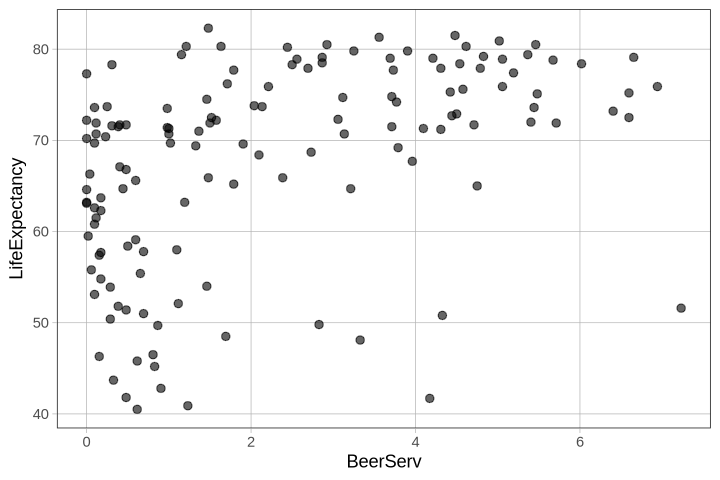

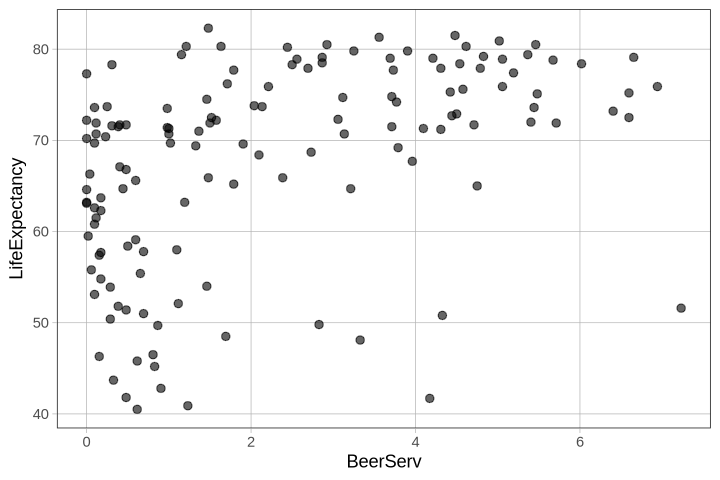

In [4]:
# ggformula version
# PLOT(Y ~ X, data = DATAFRAME) 
gf_point(LifeExpectancy ~ BeerServ, data = World)

# ggplot2 version
# ggplot(DATA, aes(X, Y)) +
#   PLOT()
ggplot(World, aes(BeerServ, LifeExpectancy)) + 
  geom_point()

We can save these plots... that will be helpful later.

In [5]:
# ggformula version
ggformula_life <- gf_point(LifeExpectancy ~ BeerServ, data = World, color = "dodgerblue")

# ggplot2 version
# ggplot(DATA, aes(X, Y)) +
#   PLOT()
ggplot2_life <- ggplot(World, aes(BeerServ, LifeExpectancy)) + 
  geom_point()

Saving these plots allows us to do things like put them in a grid.

In [6]:
# we need an extra library
library(gridExtra)


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




Warning message:
“Removed 59 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 59 rows containing missing values or values outside the scale range
(`geom_point()`).”


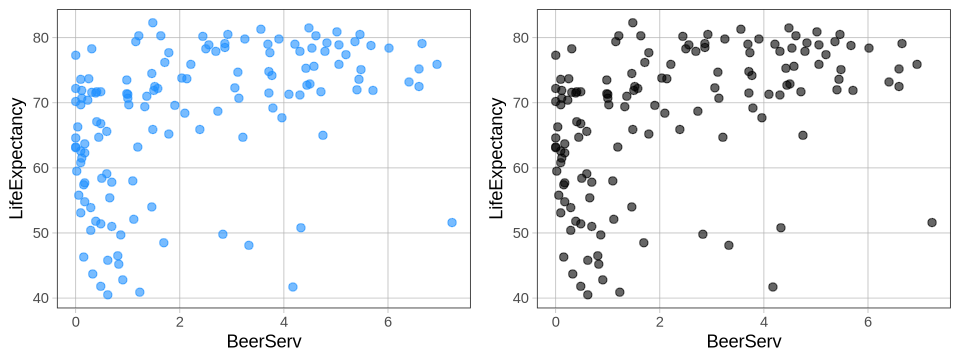

In [7]:
# this changes plot size in a jupyter notebook
options(repr.plot.width = 8, repr.plot.height = 3)

# puts the two graphs side-by-side
grid.arrange(ggformula_life, ggplot2_life, ncol=2)

# return to coursekata defaults
options(repr.plot.width = 6, repr.plot.height = 4)

### Hacking `ggplot2` for Your Own Purposes

The important thing to note about `ggplot2` is that it is the TRUE graph maker that `ggformula` uses. Because of that, you can actually mix and match. You can start with a basic `ggformula` plot and fancy it up with `ggplot2` stuff you find on the web. You just need to use a `+` if you want to chain on `ggplot2` layers.

For example, what if I google "add an arrow to ggplot2"?

Warning message in geom_segment(aes(x = 6, y = 40, xend = 7.1, yend = 50), arrow = arrow(length = unit(0.5, :
“All aesthetics have length 1, but the data has 200 rows.
ℹ Please consider using `annotate()` or provide this layer with data containing
  a single row.”
Warning message:
“Removed 59 rows containing missing values or values outside the scale range
(`geom_point()`).”


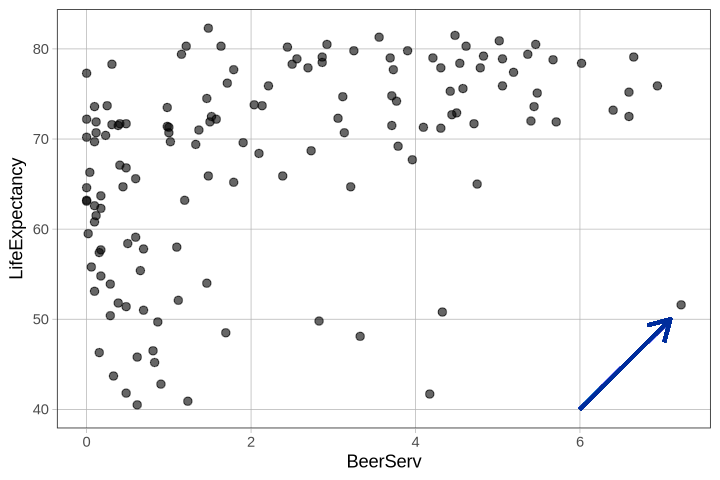

In [8]:
gf_point(LifeExpectancy ~ BeerServ, data = World) + 
  geom_segment(aes(x = 6, y = 40, xend = 7.1, yend = 50),
               arrow = arrow(length = unit(0.5, "cm")))

You can also take advantage of lots of the pre-made *themes* in `ggplot2`.

Try googling "ggplot2 themes". And you can just fancy up your graphs by including more information from other variables!

Warning message:
“Removed 59 rows containing missing values or values outside the scale range
(`geom_point()`).”


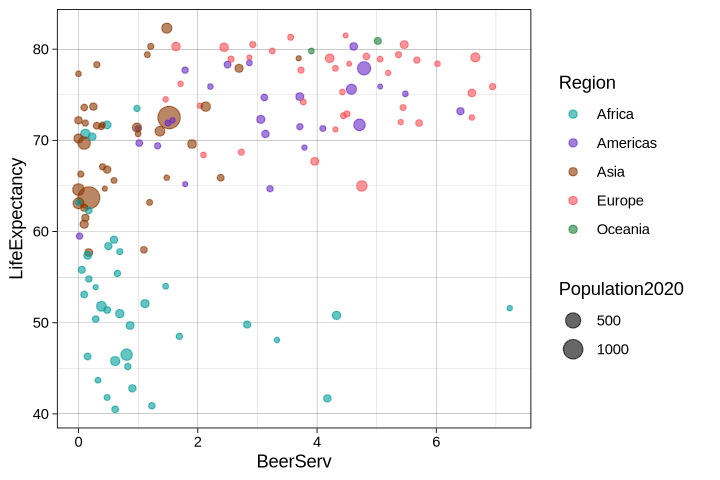

In [9]:
gf_point(LifeExpectancy ~ BeerServ, data= World, color= ~Region, size= ~Population2020) + 
  theme_linedraw()

Maybe you want to label the dots in your scatterplot. 

(Note: You'll need to specify which variable to use for the labels.)

Warning message:
“Ignoring unknown aesthetics: label”
Warning message:
“Removed 59 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 59 rows containing missing values or values outside the scale range
(`geom_text()`).”


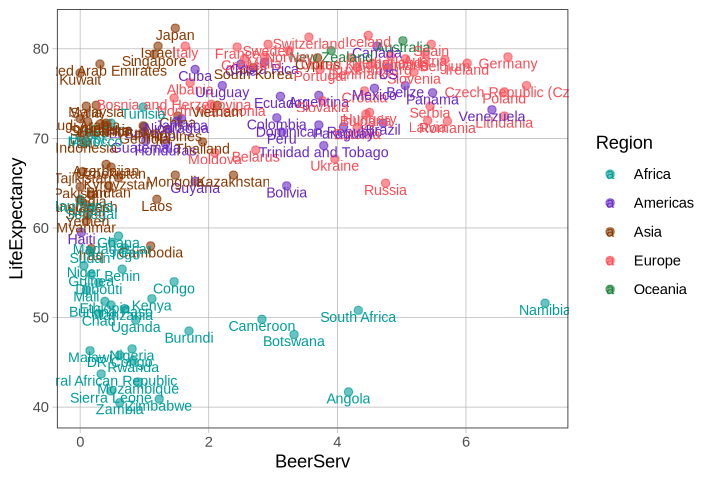

In [10]:
gf_point(LifeExpectancy ~ BeerServ, data = World, color = ~Region, label = ~Country) +
  geom_text(size = 3, nudge_y = -0.75)

# another way
#gf_point(LifeExpectancy ~ BeerServ, data = World, color = ~Region) +
#  geom_text(aes(label = Country), size = 3, nudge_y = -0.75)

## 3.0: Dotplots and Bee Swarm

This is the number 1 visualization teachers ask for!

Biggest problems with `gf_dotplot`: 
1. y-axis is meaningless. You have to count the dots yourself. 
2. Doesn't align with histograms... without a little work!

Bin width defaults to 1/30 of the range of the data. Pick better value with
`binwidth`.


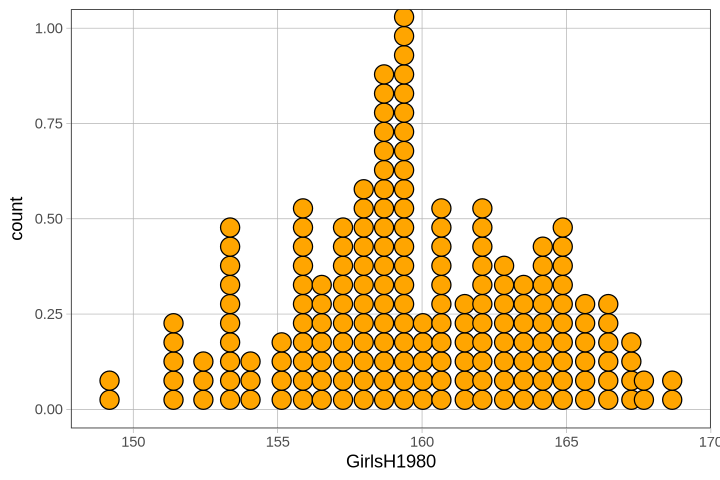

In [11]:
gf_dotplot(~ GirlsH1980, data = World, fill = "orange")

Bin width defaults to 1/30 of the range of the data. Pick better value with
`binwidth`.
Bin width defaults to 1/30 of the range of the data. Pick better value with
`binwidth`.


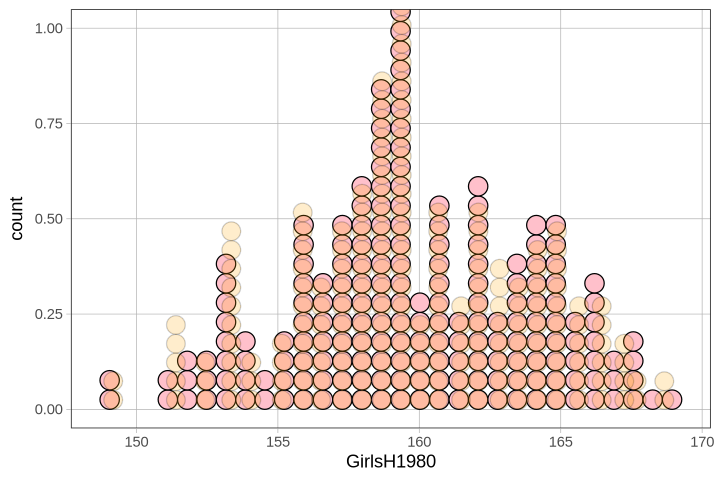

In [12]:
gf_dotplot(~ GirlsH1980, data = World, fill = "pink", method="histodot") %>%
  gf_dotplot(~ GirlsH1980, fill = "orange", alpha = .2, data = World)

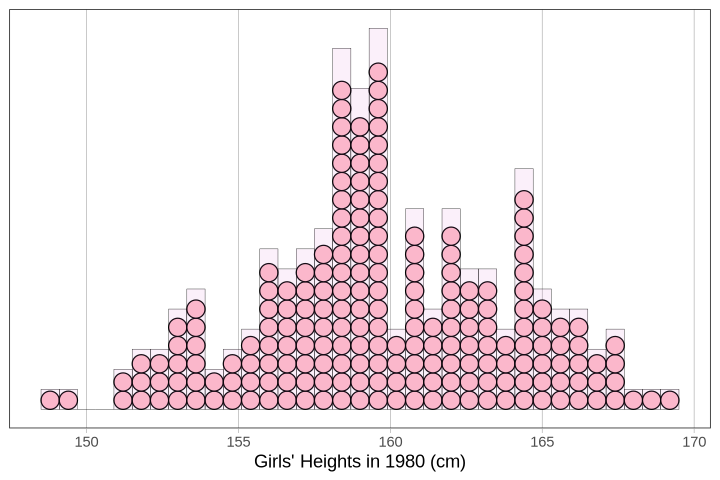

In [13]:
gf_dotplot(~ GirlsH1980, data = World, fill = "pink", method="histodot", binwidth = .6) %>%
  gf_histogram(binwidth = .6, fill = "orchid", alpha = .1) %>%
  gf_labs(x = "Girls' Heights in 1980 (cm)") +
  scale_y_continuous(NULL, breaks = NULL) 

You can use `gf_dotplot` to make "bee swarm plots" which are kind of like organized jitter plots.

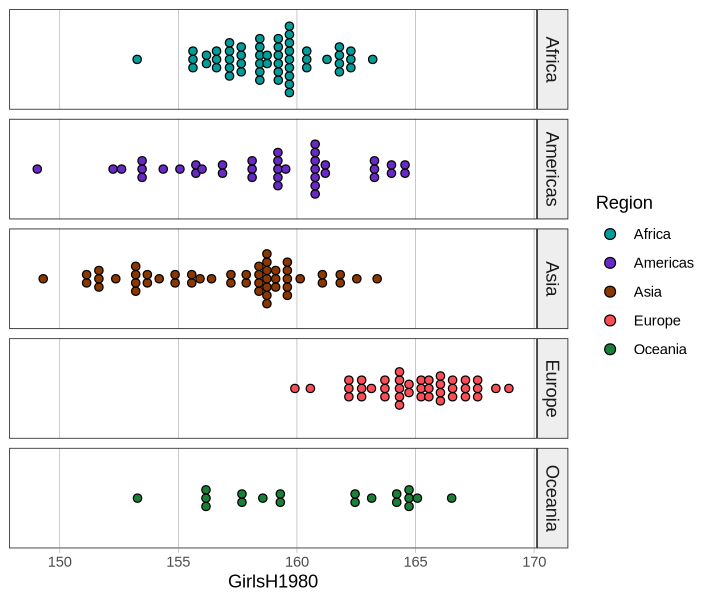

In [14]:
options(repr.plot.width = 6, repr.plot.height = 5)

gf_dotplot(~ GirlsH1980, data = World, fill = ~Region, stackdir="center", binwidth = .35) %>%
  gf_facet_grid(Region ~ .) +
  scale_y_continuous(NULL, breaks = NULL)

options(repr.plot.width = 6, repr.plot.height = 4)

## 4.0: Make Overlapping Graphs

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


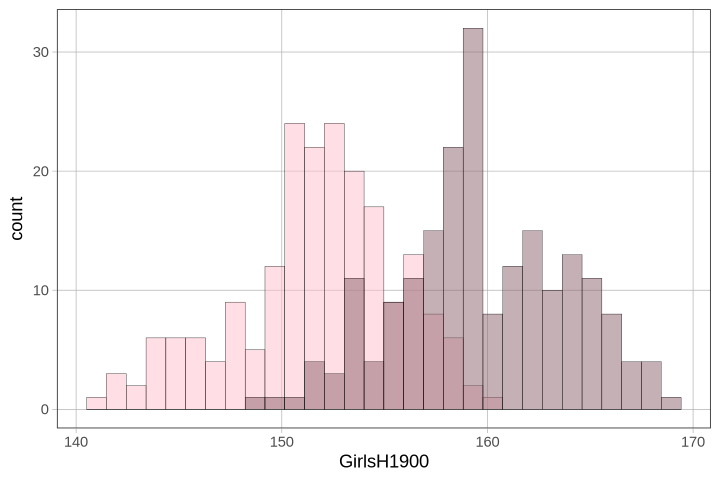

In [15]:
gf_histogram(~ GirlsH1900, data = World, fill = "pink") %>%
  gf_histogram(~ GirlsH1980, fill = "pink4")

You can add on boxplots too!

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


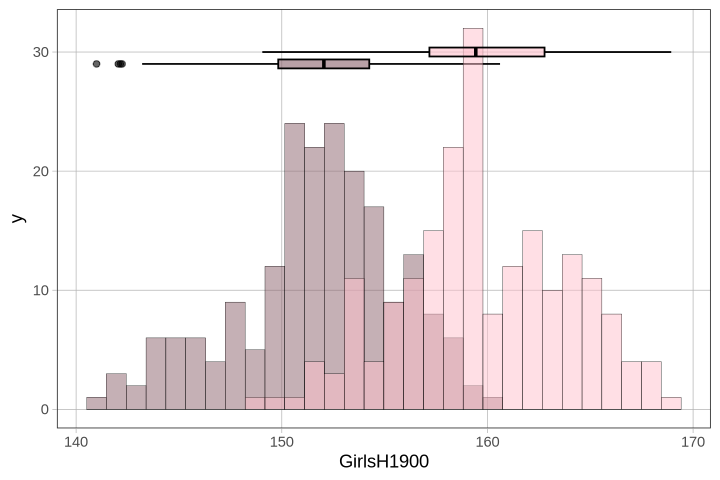

In [16]:
gf_histogram(~ GirlsH1900, data = World, fill = "pink4") %>%
  gf_boxplot(29 ~ GirlsH1900, fill = "pink4") %>%
  gf_histogram(~ GirlsH1980, fill = "pink") %>%
  gf_boxplot(30 ~ GirlsH1980, fill = "pink")

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


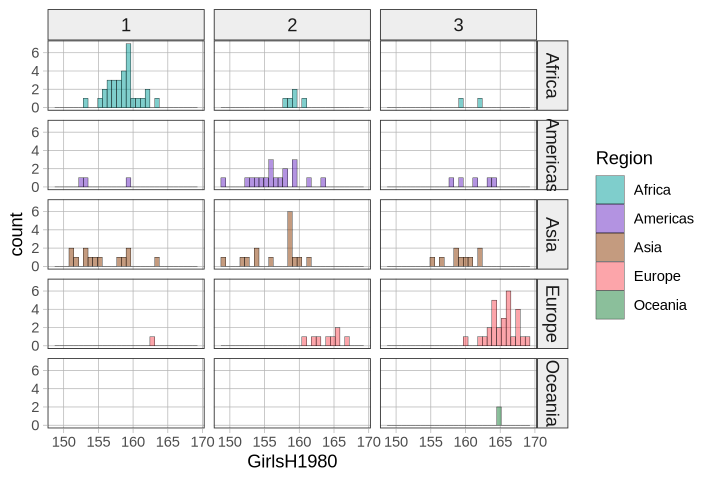

In [17]:
tempWorld <- World %>%
  select(GirlsH1900, GirlsH1980, GDPperCapita, Region) %>%
  mutate(GDPgroup = ntile(GDPperCapita, 3)) 

gf_histogram(~ GirlsH1980, data = na.omit(tempWorld), fill = ~Region) %>%
  gf_facet_grid(Region ~ GDPgroup) 


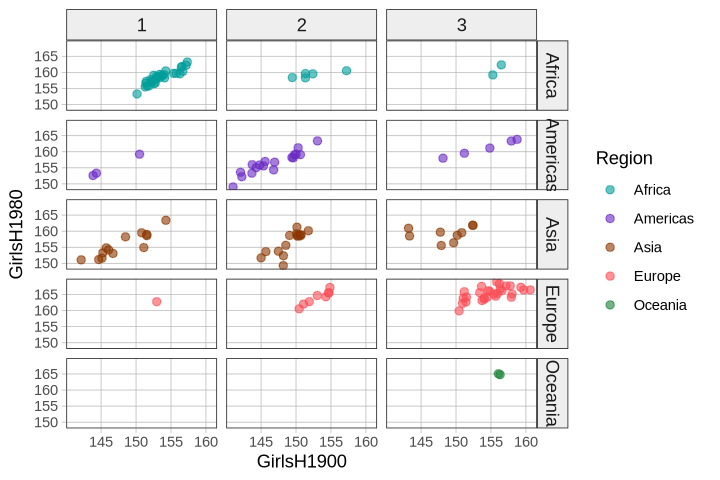

In [18]:
gf_point(GirlsH1980 ~ GirlsH1900, data = na.omit(tempWorld), color = ~Region) %>%
  gf_facet_grid(Region ~ GDPgroup) 

## 5.0: Ordered Column Graphs

You'll see these in `fivethirtyeight` and other news sources a lot.

First of all we need a new kind of graph that plots the value of a variable as the height of a bar graph. This is called `stat = "identity"` in the `ggplot2` vocabulary. Thankfully there is a `ggformula` shortcut: `gf_col` (`col` for column).


In [19]:
# a little data cleaning
# creates a new variable called Growth and saves back into World
World <- World %>%
  mutate(Growth = GirlsH1980-GirlsH1900) 


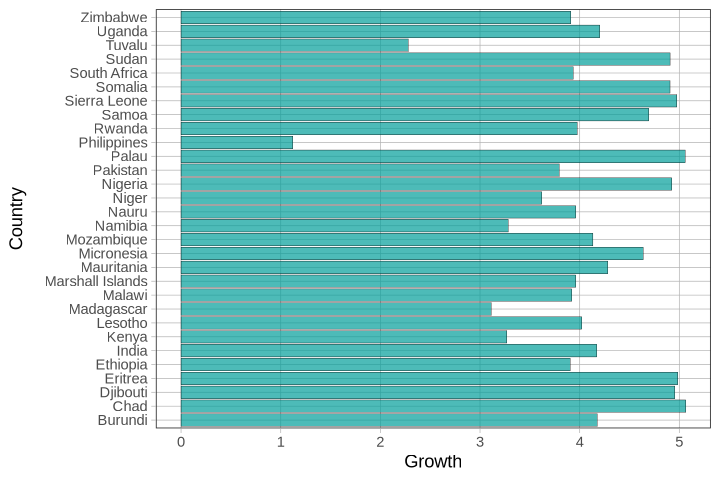

In [20]:
# how if we "arrange" the data by Growth?
World <- arrange(World, Growth)

gf_col(Country ~ Growth, data = head(World, 30)) 

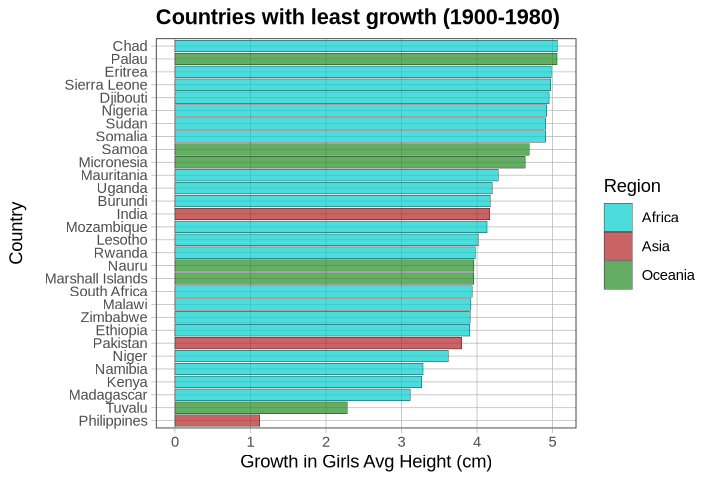

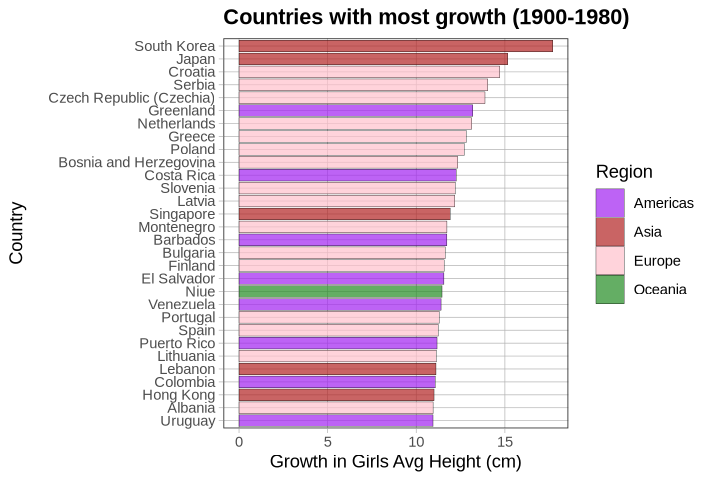

In [21]:
# we have to actually order the values of `Country` itself!
World <- arrange(World, Growth)
World$Country_ordered_by_growth <- factor(World$Country, 
  levels = World$Country[order(World$Growth)])

gf_col(Country_ordered_by_growth ~ Growth, data = head(World, 30), fill = ~Region) %>%
  gf_labs(title="Countries with least growth (1900-1980)", y="Country", x="Growth in Girls Avg Height (cm)") + 
  scale_fill_manual(values=c("cyan3", "firebrick", "forestgreen"))

gf_col(Country_ordered_by_growth ~ Growth, data = tail(World, 30), fill = ~Region) %>%
  gf_labs(title="Countries with most growth (1900-1980)", y="Country", x="Growth in Girls Avg Height (cm)") + 
  scale_fill_manual(values=c("purple", "firebrick", "pink", "forestgreen"))

## 6.0: Maps

Sometimes you need a package that isn't already installed in our CKHub (or in Deepnote or RStudio or whereever you are coding). 

We'll need two packages to make maps: `maps` and `countrycode`. These have to be installed before called with the `library()` command.

In [22]:
install.packages(c("maps","countrycode"))

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [23]:
library(maps)
library(countrycode)


Attaching package: ‘maps’


The following object is masked from ‘package:purrr’:

    map




In [24]:
# this gets detailed latitude/longitude data
world_map <- data.frame(map_data("world"))

# this just puts the ISO country code so that we can join it with our World data frame
world_map$Code <- countryname(world_map$region, destination = 'iso3c')


Warning message:
“Some values were not matched unambiguously: Ascension Island, Azores, Barbuda, Canary Islands, Chagos Archipelago, Grenadines, Heard Island, Madeira Islands, Micronesia, Saba, Saint Martin, Siachen Glacier, Sint Eustatius, Virgin Islands
To fix unmatched values, please use the `custom_match` argument. If you think the default matching rules should be improved, please file an issue at https://github.com/vincentarelbundock/countrycode/issues
”
Warning message:
“Some values were not matched unambiguously: Kosovo
To fix unmatched values, please use the `custom_match` argument. If you think the default matching rules should be improved, please file an issue at https://github.com/vincentarelbundock/countrycode/issues
”


In [25]:
# joins map data with our World data frame
world_map_data <- left_join(world_map, World, by="Code")


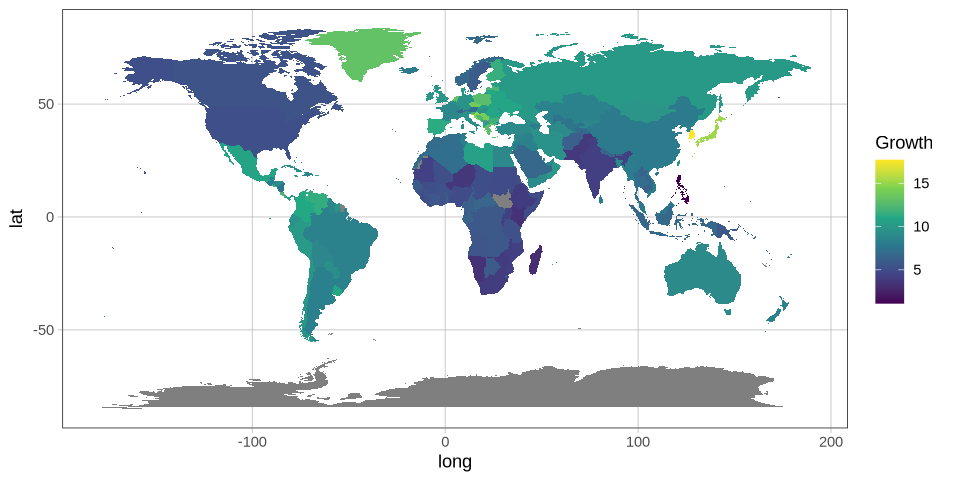

In [26]:
options(repr.plot.width = 8, repr.plot.height = 4)

ggplot(world_map_data, aes(long, lat, group = group)) +
  geom_polygon(aes(fill = Growth)) 
     
# changes back to default
options(repr.plot.width = 6, repr.plot.height = 4)

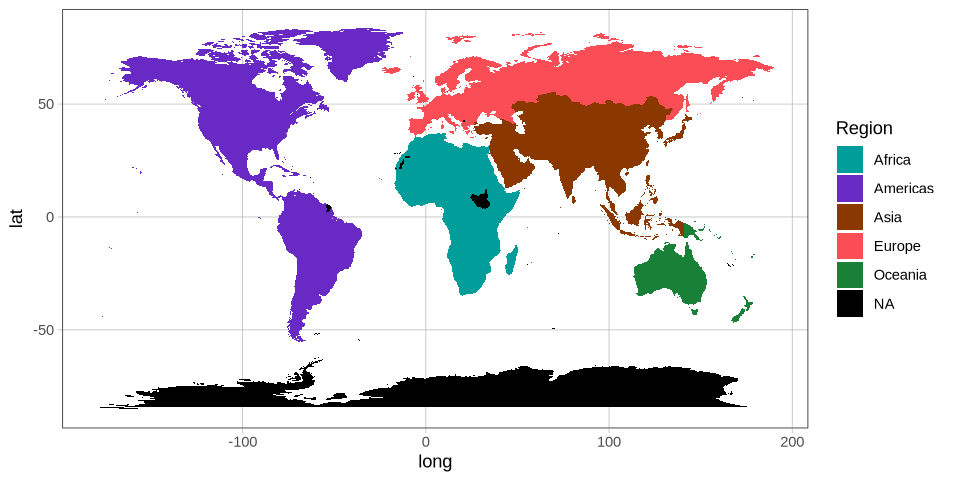

In [27]:
options(repr.plot.width = 8, repr.plot.height = 4)

ggplot(world_map_data, aes(long, lat, group = group)) +
  geom_polygon(aes(fill = Region)) +
  scale_fill_discrete(na.value = "black")
     
# changes back to default
options(repr.plot.width = 6, repr.plot.height = 4)